In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
import pickle

In [ ]:
df = pd.read_csv("advertising.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [ ]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

In [ ]:
df.shape

(1000, 10)

In [ ]:
def value_count(col):
  return df[col].value_counts(normalize=True)*100

value_count('Clicked on Ad')

,proportion
Clicked on Ad,
0,50.0
1,50.0


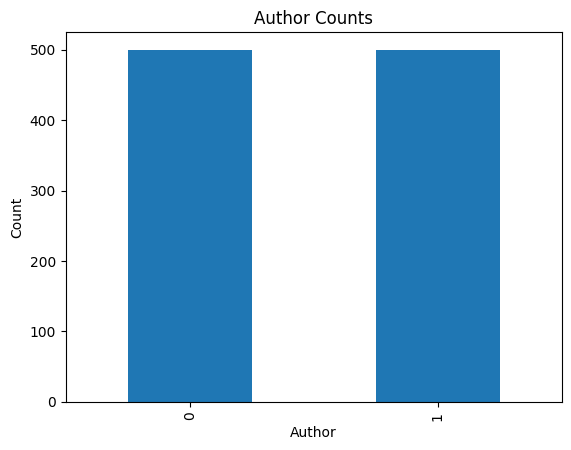

In [ ]:
df['Clicked on Ad'].value_counts().plot(kind='bar')
plt.title("Author Counts")
plt.xlabel("Author")
plt.ylabel("Count")
plt.show()

In [ ]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

In [ ]:
def check_data(df):
  return df.isnull().sum(), df.duplicated().sum(), df.dtypes

missing_value,duplicate_value,data_type = check_data(df)


In [ ]:
missing_value

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Ad Topic Line,0
City,0
Male,0
Country,0
Timestamp,0
Clicked on Ad,0


In [ ]:
duplicate_value

np.int64(0)

In [ ]:
data_type

,0
Daily Time Spent on Site,float64
Age,int64
Area Income,float64
Daily Internet Usage,float64
Ad Topic Line,object
City,object
Male,int64
Country,object
Timestamp,object
Clicked on Ad,int64


In [ ]:
def skew_check(df):
  return df.skew(numeric_only=True)

skew_check(df)

,0
Daily Time Spent on Site,-0.371760
Age,0.479142
Area Income,-0.650373
Daily Internet Usage,-0.033537
Male,0.076169
Clicked on Ad,0.000000


In [ ]:
import numpy as np

def detect_outliers(df):
    outlier_dict = {}

    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_dict[col] = len(outliers)

    return outlier_dict

print(detect_outliers(df))

{'Daily Time Spent on Site': 0, 'Age': 0, 'Area Income': 9, 'Daily Internet Usage': 0, 'Male': 0, 'Clicked on Ad': 0}


In [ ]:
# for col in df.select_dtypes(include="number").columns:
#   plt.figure()
#   sns.boxplot(x=df[col])
#   plt.title(col)
#   plt.show()

In [ ]:
def time_date(time_col):
  df[time_col] = pd.to_datetime(df[time_col])

  start_date = df[time_col].min()
  end_date = df[time_col].max()

  total_days = end_date-start_date

  return start_date,end_date,total_days

start_date,end_date,total_days = time_date('Timestamp')

print("Start date",start_date)
print("End date", end_date)
print("Total days",total_days)

Start date 2016-01-01 02:52:10
End date 2016-07-24 00:22:16
Total days 204 days 21:30:06


In [ ]:
df['Timestamp']

,Timestamp
0,2016-03-27 00:53:11
1,2016-04-04 01:39:02
2,2016-03-13 20:35:42
3,2016-01-10 02:31:19
4,2016-06-03 03:36:18
...,...
995,2016-02-11 21:49:00
996,2016-04-22 02:07:01
997,2016-02-01 17:24:57
998,2016-03-24 02:35:54


In [ ]:
def new_column(date):
  df[date] = pd.to_datetime(df[date])
  df['Hour'] = df[date].dt.hour
  df['Day'] = df[date].dt.dayofweek
  return df

hour = new_column('Timestamp')
hour.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Hour,Day
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,0,6
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,1,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,20,6
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,2,6
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,3,4


In [ ]:
df.isnull().sum()

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Ad Topic Line,0
City,0
Male,0
Country,0
Timestamp,0
Clicked on Ad,0


In [ ]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad', 'Hour', 'Day'],
      dtype='object')

In [ ]:
X = df.drop(['Ad Topic Line','City','Male','Country','Timestamp','Clicked on Ad'], axis=1)
y = df['Clicked on Ad']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.95
[[ 86   3]
 [  7 104]]


In [ ]:
train_pred = pipeline.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

test_pred = pipeline.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.97625
Test Accuracy: 0.95


In [ ]:
!pip install scikit-learn==1.6.1

In [ ]:
import os
import pickle

# current folder check करो
print(os.getcwd())

# model folder बनाओ
folder_path = os.path.join(os.getcwd(), "model")
os.makedirs(folder_path, exist_ok=True)

# file path बनाओ
file_path = os.path.join(folder_path, "logistic.pkl")

# save model
with open(file_path, 'wb') as f:
    pickle.dump(pipeline, f)

print("Model saved at:", file_path)

/content
Model saved at: /content/model/logistic.pkl


In [ ]:
probs = pipeline.predict_proba(X_test)

print(probs[:10])

[[9.90500496e-03 9.90094995e-01]
 [4.06619175e-04 9.99593381e-01]
 [9.13062711e-04 9.99086937e-01]
 [5.17736428e-03 9.94822636e-01]
 [9.90535125e-01 9.46487498e-03]
 [5.12596147e-01 4.87403853e-01]
 [9.70789864e-01 2.92101356e-02]
 [1.45677400e-04 9.99854323e-01]
 [9.91557196e-01 8.44280420e-03]
 [3.57831208e-05 9.99964217e-01]]
